<h1 style="color:rgb(242, 176, 235);">Import modules</h1>

Configuration du chemin projet et import du chargeur USA Swimming.

In [32]:
import json
import pandas as pd
import pyarrow.parquet as pq
from setup_env import ensure_project_root
PROJECT_DIR = ensure_project_root()
from services.usaswimming_competitions_data_loader import DEFAULT_USASWIMMING_COMPETITIONS_DIR, DEFAULT_USASWIMMING_PARQUET_DIR, UsaswimmingCompetitionsDataLoader


<h1 style="color:rgb(242, 176, 235);">Loading datasets</h1>

In [33]:
USA_SWIMMING_DIR = DEFAULT_USASWIMMING_COMPETITIONS_DIR
CLEANED_DIR = DEFAULT_USASWIMMING_PARQUET_DIR
loader = UsaswimmingCompetitionsDataLoader(base_dir=USA_SWIMMING_DIR, parquet_dir=CLEANED_DIR)
written_files = loader.build_parquet_cache(overwrite=False)
parquet_files = sorted(CLEANED_DIR.glob('*.parquet'))
total_rows = sum((pq.ParquetFile(file).metadata.num_rows for file in parquet_files))
print(f'Cache Parquet pret dans : {CLEANED_DIR}')
print(f'Fichiers Parquet annuels disponibles : {len(parquet_files)}')
print(f'Nombre total de performances : {total_rows:,}')


Cache Parquet pret dans : /Users/nouhailaimaneabbassi/Desktop/Pacing/data/processed/usaswimming/_parquet_cache
Fichiers Parquet annuels disponibles : 37
Nombre total de performances : 176,664,310


In [35]:
if parquet_files:
    sample_df = pd.read_parquet(parquet_files[0]).head(1)
else:
    raise FileNotFoundError(f'Aucun fichier Parquet trouve dans {CLEANED_DIR}')
sample_row = sample_df.iloc[0].copy()
sample_swimmer = sample_row.get('swimmer')
if isinstance(sample_swimmer, str) and sample_swimmer.strip():
    sample_row['swimmer'] = json.loads(sample_swimmer)
print('La premiere ligne est : ')
print(sample_row)
print('Le swimmer information :')
print(sample_row['swimmer'])


La premiere ligne est : 
Year                                                               1990
SourceFile                                    1990_Archived_Record.json
Meet                                               1990 Archived Record
SwimDate                                            1990-01-01 00:00:00
Location                                                           None
Country                                                            None
Event                                                       1500 FR LCM
Distance                                                           1500
Stroke                                                               FR
Course                                                              LCM
PoolLength                                                         50.0
Tour                                                         TimedFinal
Rank                                                                NaN
Club                                   

In [36]:
from typing import Any
all_columns = set[Any]()
for file in parquet_files:
    cols = pd.read_parquet(file, engine='pyarrow').columns
    all_columns.update(cols)
print(sorted(all_columns))
print('Nombre total de colonnes distinctes :', len(all_columns))


['AgeGroup', 'Age_at_Performance', 'Club', 'Country', 'Course', 'Distance', 'Event', 'Gender', 'Location', 'Meet', 'Name', 'Nationality', 'PoolLength', 'Rank', 'Session', 'SourceFile', 'Speed', 'Status', 'Stroke', 'SwimDate', 'SwimTime', 'SwimTimeSeconds', 'TimeStandard', 'Tour', 'Year', 'Year_of_birth', 'swimmer']
Nombre total de colonnes distinctes : 27


<h1 style="color:rgb(242, 176, 235);">Data validation</h1>

<h5 style="color:rgb(245, 72, 227);">Meet</h5>

In [16]:
unique_meets = set()
total_meets = 0
invalid_meets = 0
for file in parquet_files:
    try:
        meet_col = pd.read_parquet(file, columns=['Meet'], engine='pyarrow')['Meet']
    except ValueError:
        continue
    invalid_mask = meet_col.isna() | (meet_col.astype(str).str.strip() == '')
    invalid_meets += int(invalid_mask.sum())
    meet_names = meet_col[~invalid_mask].astype(str).str.strip()
    total_meets += len(meet_names)
    unique_meets.update(meet_names.unique())
print('Nombre total de lignes avec ')
print('     Meet valides :', total_meets)
print('     Meet distincts :', len(unique_meets))
print('     Meet None ou vides :', invalid_meets)


Nombre total de lignes avec 
     Meet valides : 176664310
     Meet distincts : 177270
     Meet None ou vides : 0


<h5 style="color:rgb(245, 72, 227);">Event</h5>

In [ ]:
def _event_sort_key(event: str) -> tuple[int, str, str]:
    parts = event.split()
    try:
        distance = int(parts[0])
    except (IndexError, ValueError):
        distance = 0
    stroke = parts[1] if len(parts) > 1 else ''
    course = parts[2] if len(parts) > 2 else ''
    return (distance, stroke, course)
unique_events = set()
total_events = 0
invalid_events = 0
for file in parquet_files:
    try:
        event_col = pd.read_parquet(file, columns=['Event'], engine='pyarrow')['Event']
    except ValueError:
        continue
    invalid_mask = event_col.isna() | (event_col.astype(str).str.strip() == '')
    invalid_events += int(invalid_mask.sum())
    event_names = event_col[~invalid_mask].astype(str).str.strip()
    total_events += len(event_names)
    unique_events.update(event_names.unique())
    
ordered_events = sorted(unique_events, key=_event_sort_key)
print('Nombre total de lignes avec ')
print('     Event valides :', total_events)
print('     Event distincts :', len(ordered_events))
print('     Event None ou vides :', invalid_events)
print()
print('Liste complete des Event distincts :')
for i, event in enumerate(ordered_events, start=1):
    print(f'{i:2d}. {event}')


Nombre total de lignes avec 
     Event valides : 176664310
     Event distincts : 68
     Event None ou vides : 0

Liste complete des Event distincts :
 1. 50 BK LCM
 2. 50 BK SCM
 3. 50 BK SCY
 4. 50 BR LCM
 5. 50 BR SCM
 6. 50 BR SCY
 7. 50 FL LCM
 8. 50 FL SCM
 9. 50 FL SCY
10. 50 FR LCM
11. 50 FR SCM
12. 50 FR SCY
13. 100 BK LCM
14. 100 BK SCM
15. 100 BK SCY
16. 100 BR LCM
17. 100 BR SCM
18. 100 BR SCY
19. 100 FL LCM
20. 100 FL SCM
21. 100 FL SCY
22. 100 FR LCM
23. 100 FR SCM
24. 100 FR SCY
25. 100 IM SCM
26. 100 IM SCY
27. 200 BK LCM
28. 200 BK SCM
29. 200 BK SCY
30. 200 BR LCM
31. 200 BR SCM
32. 200 BR SCY
33. 200 FL LCM
34. 200 FL SCM
35. 200 FL SCY
36. 200 FR LCM
37. 200 FR SCM
38. 200 FR SCY
39. 200 FR-R LCM
40. 200 FR-R SCM
41. 200 FR-R SCY
42. 200 IM LCM
43. 200 IM SCM
44. 200 IM SCY
45. 200 MED-R LCM
46. 200 MED-R SCM
47. 200 MED-R SCY
48. 400 FR LCM
49. 400 FR SCM
50. 400 FR-R LCM
51. 400 FR-R SCM
52. 400 FR-R SCY
53. 400 IM LCM
54. 400 IM SCM
55. 400 IM SCY
56. 400 MED-R

<h5 style="color:rgb(245, 72, 227);">Distance</h5>

In [18]:
unique_distances = set()
total_distances = 0
invalid_distances = 0
for file in parquet_files:
    try:
        distance_col = pd.read_parquet(file, columns=['Distance'], engine='pyarrow')['Distance']
    except ValueError:
        continue
    invalid_mask = distance_col.isna()
    invalid_distances += int(invalid_mask.sum())
    distance_vals = pd.to_numeric(distance_col[~invalid_mask], errors='coerce')
    valid_mask = distance_vals.notna()
    invalid_distances += int((~valid_mask).sum())
    distance_vals = distance_vals[valid_mask].astype(int)
    total_distances += len(distance_vals)
    unique_distances.update(distance_vals.unique())
ordered_distances = sorted(unique_distances)
print('Nombre total de lignes avec ')
print('     Distance valides :', total_distances)
print('     Distance distinctes :', len(ordered_distances))
print('     Distance None ou invalides :', invalid_distances)
print()
print('Liste des Distance distinctes :')
for distance in ordered_distances:
    print(distance)


Nombre total de lignes avec 
     Distance valides : 176664310
     Distance distinctes : 9
     Distance None ou invalides : 0

Liste des Distance distinctes :
50
100
200
400
500
800
1000
1500
1650


<h5 style="color:rgb(245, 72, 227);">Stroke</h5>

Type de nage (FR, BK, BR, FL, IM, relais).

In [19]:
unique_strokes = set()
total_strokes = 0
invalid_strokes = 0
for file in parquet_files:
    try:
        stroke_col = pd.read_parquet(file, columns=['Stroke'], engine='pyarrow')['Stroke']
    except ValueError:
        continue
    invalid_mask = stroke_col.isna() | (stroke_col.astype(str).str.strip() == '')
    invalid_strokes += int(invalid_mask.sum())
    stroke_names = stroke_col[~invalid_mask].astype(str).str.strip()
    total_strokes += len(stroke_names)
    unique_strokes.update(stroke_names.unique())
ordered_strokes = sorted(unique_strokes)
print('Nombre total de lignes avec ')
print('     Stroke valides :', total_strokes)
print('     Stroke distincts :', len(ordered_strokes))
print('     Stroke None ou vides :', invalid_strokes)
print()
print('Liste des Stroke distincts :')
for stroke in ordered_strokes:
    print(stroke)


Nombre total de lignes avec 
     Stroke valides : 175645426
     Stroke distincts : 5
     Stroke None ou vides : 1018884

Liste des Stroke distincts :
BK
BR
FL
FR
IM


<h5 style="color:rgb(245, 72, 227);">Course</h5>

Type de bassin (LCM, SCM, SCY).

In [20]:
unique_courses = set()
total_courses = 0
invalid_courses = 0
for file in parquet_files:
    try:
        course_col = pd.read_parquet(file, columns=['Course'], engine='pyarrow')['Course']
    except ValueError:
        continue
    invalid_mask = course_col.isna() | (course_col.astype(str).str.strip() == '')
    invalid_courses += int(invalid_mask.sum())
    course_names = course_col[~invalid_mask].astype(str).str.strip()
    total_courses += len(course_names)
    unique_courses.update(course_names.unique())
ordered_courses = sorted(unique_courses)
print('Nombre total de lignes avec ')
print('     Course valides :', total_courses)
print('     Course distinctes :', len(ordered_courses))
print('     Course None ou vides :', invalid_courses)
print()
print('Liste des Course distinctes :')
for course in ordered_courses:
    print(course)


Nombre total de lignes avec 
     Course valides : 176664310
     Course distinctes : 3
     Course None ou vides : 0

Liste des Course distinctes :
LCM
SCM
SCY


<h5 style="color:rgb(245, 72, 227);">AgeGroup</h5>

Tranches d'age des performances.

In [38]:
from collections import Counter
agegroup_counts = Counter()
for file in parquet_files:
    try:
        s = pd.read_parquet(file, columns=['AgeGroup'], engine='pyarrow')['AgeGroup']
    except Exception:
        continue
    s_clean = s.fillna('').astype(str).str.strip()
    s_clean = s_clean[s_clean != '']
    agegroup_counts.update(s_clean.value_counts().to_dict())
ordered = sorted(agegroup_counts.keys())
print("Nombre d'AgeGroup distincts :", len(ordered))
print('Performances avec AgeGroup non vide :', sum(agegroup_counts.values()))
for ag in ordered:
    print(f'{ag}: {agegroup_counts[ag]:,}')


Nombre d'AgeGroup distincts : 6
Performances avec AgeGroup non vide : 176664310
10 & Under: 39,747,445
11-12: 45,379,869
13-14: 40,067,022
15-18: 42,178,976
19 & Over: 8,269,538
Not Applicable: 1,021,460


<h5 style="color:rgb(245, 72, 227);">Swimmer</h5>

Nageurs distincts via la colonne Name.

In [22]:
parquet_files = sorted(CLEANED_DIR.glob('*.parquet'))
unique_swimmers = set()
total_swimmer_rows = 0
for file in parquet_files:
    df = pd.read_parquet(file)
    swimmer_names = df['Name'].dropna().astype(str).str.strip()
    swimmer_names = swimmer_names[swimmer_names != '']
    total_swimmer_rows += len(swimmer_names)
    unique_swimmers.update(swimmer_names.tolist())
print('Nombre total de lignes swimmer (non vides) :', total_swimmer_rows)
print('Nombre total de swimmers uniques           :', len(unique_swimmers))


Nombre total de lignes swimmer (non vides) : 176664310
Nombre total de swimmers uniques           : 2002496


<h5 style="color:rgb(245, 72, 227);">Year_of_birth</h5>

Annees de naissance renseignees.

In [40]:
unique_years_of_birth = set()
total_years_of_birth = 0
invalid_years_of_birth = 0
for file in parquet_files:
    try:
        yob_col = pd.read_parquet(file, columns=['Year_of_birth'], engine='pyarrow')['Year_of_birth']
    except ValueError:
        continue
    invalid_mask = yob_col.isna()
    invalid_years_of_birth += int(invalid_mask.sum())
    yob_vals = pd.to_numeric(yob_col[~invalid_mask], errors='coerce')
    valid_mask = yob_vals.notna()
    invalid_years_of_birth += int((~valid_mask).sum())
    yob_vals = yob_vals[valid_mask].astype(int)
    total_years_of_birth += len(yob_vals)
    unique_years_of_birth.update(yob_vals.unique())
ordered_years_of_birth = sorted(unique_years_of_birth)
print('Nombre total de lignes avec ')
print('     Year_of_birth valides :', total_years_of_birth)
print('     Year_of_birth distinctes :', len(ordered_years_of_birth))
print('     Year_of_birth None ou invalides :', invalid_years_of_birth)
print()
print('Liste complete des Year_of_birth distinctes :')
if ordered_years_of_birth:
    for i, yob in enumerate(ordered_years_of_birth, start=1):
        print(f'{i:2d}. {yob}')
else:
    print('(aucune valeur)')


Nombre total de lignes avec 
     Year_of_birth valides : 0
     Year_of_birth distinctes : 0
     Year_of_birth None ou invalides : 176664310

Liste complete des Year_of_birth distinctes :
(aucune valeur)


<h1 style="color:rgb(242, 176, 235);">Data visualizations</h1>

Lignes chargees pour 1500 FR LCM (toutes annees) : 369,086
Epreuve : 1500 FR LCM
AgeGroups traces : ['10 & Under', '11-12', '13-14', '15-18', '19 & Over']
Performances dans le couloir : 369,086
Nageur cible : Matt Hooper - 15 perf.


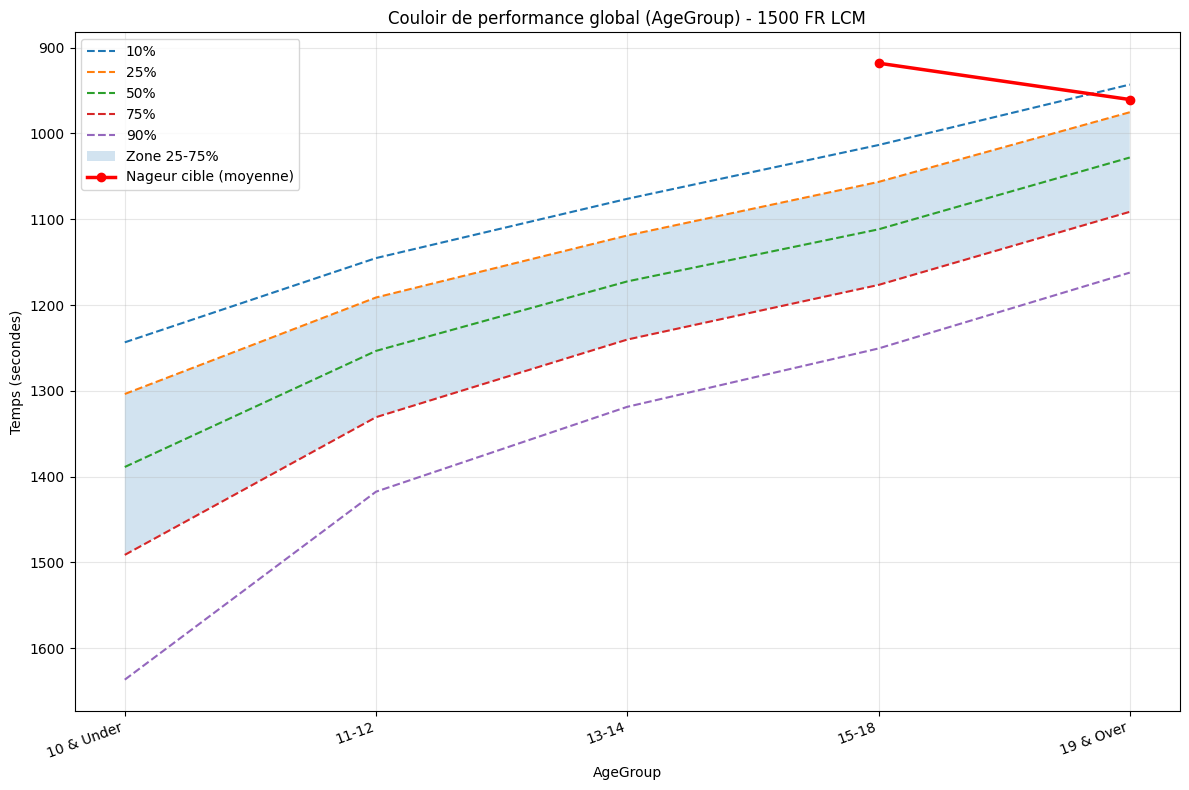

In [46]:
%matplotlib inline

import importlib
import matplotlib.pyplot as plt
from IPython.display import display
from setup_env import ensure_project_root

if "loader" not in globals():
    ensure_project_root()
    from services.usaswimming_competitions_data_loader import (
        DEFAULT_USASWIMMING_COMPETITIONS_DIR,
        DEFAULT_USASWIMMING_PARQUET_DIR,
        UsaswimmingCompetitionsDataLoader,
    )

    loader = UsaswimmingCompetitionsDataLoader(base_dir=DEFAULT_USASWIMMING_COMPETITIONS_DIR, parquet_dir=DEFAULT_USASWIMMING_PARQUET_DIR)

import services.graph_service as graph_service_module
import services.usaswimming_competitions_data_loader as usaswimming_loader_module

importlib.reload(usaswimming_loader_module)
importlib.reload(graph_service_module)
if "loader" in globals():
    loader = usaswimming_loader_module.UsaswimmingCompetitionsDataLoader(base_dir=usaswimming_loader_module.DEFAULT_USASWIMMING_COMPETITIONS_DIR, parquet_dir=usaswimming_loader_module.DEFAULT_USASWIMMING_PARQUET_DIR)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "1500 FR LCM"

CORRIDOR_COLS = ["Event", "SwimTimeSeconds", "AgeGroup", "Gender", "Name"]
df_viz = loader.load(event=nom_event, columns=CORRIDOR_COLS)
print(f"Lignes chargees pour {nom_event} (toutes annees) : {len(df_viz):,}")

nom_nageur = "Matt Hooper"

fig, meta = service_graphe.build_figure(
    graph_service_module.GRAPHES_PAR_KEY["performance_corridor_global_by_agegroup"],
    df_viz,
    nom_event=nom_event,
    nom_nageur=nom_nageur,
    min_points=100,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    print(f"Epreuve : {nom_event}")
    print(f"AgeGroups traces : {meta.get('agegroups_available')}")
    print(f"Performances dans le couloir : {meta.get('points_count'):,}")
    if meta.get("swimmer_name"):
        print(
            f"Nageur cible : {meta.get('swimmer_name')} "
            f"- {meta.get('points_swimmer')} perf."
        )
    elif nom_nageur and meta.get("swimmer_message"):
        print(meta.get("swimmer_message"))
    display(fig)
    plt.close(fig)